In [19]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, MaxPooling2D, Dropout, Conv2D
from tensorflow.keras.optimizers import Adam
import datetime

**Match contours to license plate or character template**

In [20]:
def find_contours(dimensions, img):
    cntrs, _ = cv2.findContours(img.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    lower_width, upper_width, lower_height, upper_height = dimensions
    
    cntrs = sorted(cntrs, key=cv2.contourArea, reverse=True)[:15]
    
    ii = cv2.imread('contour.jpg')
    
    x_cntr_list = []
    target_contours = []
    img_res = []
    
    for cntr in cntrs:
        intX, intY, intWidth, intHeight = cv2.boundingRect(cntr)
        
        if lower_width < intWidth < upper_width and lower_height < intHeight < upper_height:
            x_cntr_list.append(intX)

            char_copy = np.zeros((44, 24))
            char = img[intY:intY + intHeight, intX:intX + intWidth]
            char = cv2.resize(char, (20, 40))
            
            cv2.rectangle(ii, (intX,intY), (intWidth + intX, intY + intHeight), (50, 21, 200), 2)
            plt.imshow(ii, cmap='gray')

            char = cv2.subtract(255, char)

            char_copy[2:42, 2:22] = char
            char_copy[0:2, :] = 0
            char_copy[:, 0:2] = 0
            char_copy[42:44, :] = 0
            char_copy[:, 22:24] = 0

            img_res.append(char_copy)

    plt.show()
    
    indices = sorted(range(len(x_cntr_list)), key=lambda k: x_cntr_list[k])
    img_res_copy = [img_res[idx] for idx in indices]
    
    return np.array(img_res_copy)

**Find characters in the resulting images**

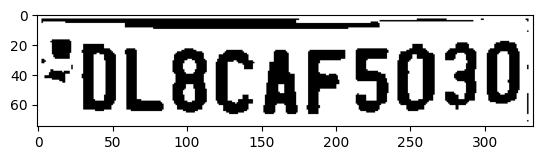

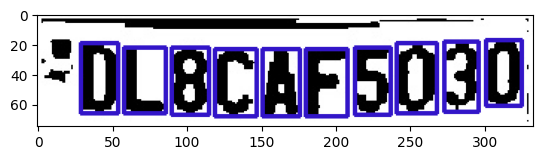

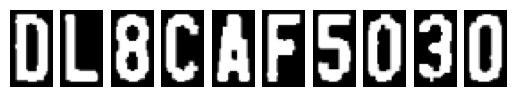

In [21]:
def segment_characters(image):
    img_lp = cv2.resize(image, (333, 75))
    img_gray_lp = cv2.cvtColor(img_lp, cv2.COLOR_BGR2GRAY)
    _, img_binary_lp = cv2.threshold(img_gray_lp, 200, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    img_binary_lp = cv2.erode(img_binary_lp, (3,3))
    img_binary_lp = cv2.dilate(img_binary_lp, (3,3))

    LP_WIDTH = img_binary_lp.shape[0]
    LP_HEIGHT = img_binary_lp.shape[1]

    img_binary_lp[0:3,:] = 255
    img_binary_lp[:,0:3] = 255
    img_binary_lp[72:75,:] = 255
    img_binary_lp[:,330:333] = 255

    dimensions = [LP_WIDTH / 6,
                  LP_WIDTH / 2,
                  LP_HEIGHT / 10,
                  2 * LP_HEIGHT / 3]
    
    plt.imshow(img_binary_lp, cmap='gray')
    plt.show()
    
    cv2.imwrite('contour.jpg', img_binary_lp)

    return find_contours(dimensions, img_binary_lp)

# Load image and segment characters
img = cv2.imread('car_plate.png')
char_list = segment_characters(img)

# Display segmented characters
for i in range(len(char_list)):
    plt.subplot(1, len(char_list), i + 1)
    plt.imshow(char_list[i], cmap='gray')
    plt.axis('off')
plt.show()


**Prepare data generators for training and validation sets**

In [22]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                    width_shift_range=0.1,
                                    height_shift_range=0.1)

train_generator = train_datagen.flow_from_directory(
        'data/train',
        target_size=(28,28),
        batch_size=1,
        class_mode='categorical')

validation_generator = train_datagen.flow_from_directory(
        'data/val',
        target_size=(28,28),
        batch_size=1,
        class_mode='categorical')

# Build the model
model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape=(28, 28, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(36, activation='softmax'))

# Compile the model with an updated optimizer
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.00001), metrics=['accuracy'])

# Define a callback to stop training early based on validation accuracy
class StopTrainingCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        val_accuracy = logs.get('val_accuracy')
        if val_accuracy is not None and val_accuracy > 0.992:
            self.model.stop_training = True

Found 864 images belonging to 36 classes.
Found 216 images belonging to 36 classes.


C:\Users\prati\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Set up TensorBoard logging**

In [23]:
log_dir="logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir)

batch_size = 1
callbacks = [tensorboard_callback, StopTrainingCallback()]

In [ ]:
model.fit(
      train_generator,
      steps_per_epoch=train_generator.samples // batch_size,
      validation_data=validation_generator,
      validation_steps=validation_generator.samples // batch_size,
      epochs=80,
      callbacks=callbacks)

Epoch 1/10


C:\Users\prati\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


864/864 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.0342 - loss: 3.5945 - val_accuracy: 0.1019 - val_loss: 3.4937
Epoch 2/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 0s 45us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 3/10
 10/864 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.0211 - loss: 3.5504    

C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2032.0_x64__qbz5n2kfra8p0\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)


864/864 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.0929 - loss: 3.4745 - val_accuracy: 0.2315 - val_loss: 3.3471
Epoch 4/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 0s 23us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 5/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.1613 - loss: 3.3554 - val_accuracy: 0.3241 - val_loss: 3.1616
Epoch 6/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 0s 21us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 7/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.2769 - loss: 3.1320 - val_accuracy: 0.4861 - val_loss: 2.8846
Epoch 8/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 0s 19us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 9/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.3651 - loss: 2.8645 - val_accuracy: 0.6111 - val_loss: 2.5345
Epoch 10/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 0s 25us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00


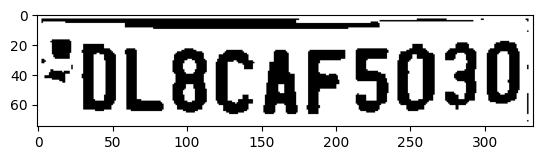

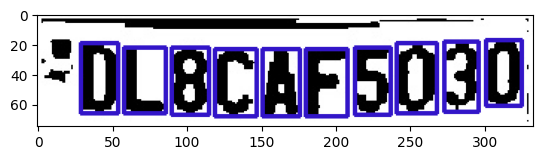

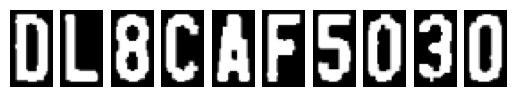

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Detected Plate Number: 0L604F6060


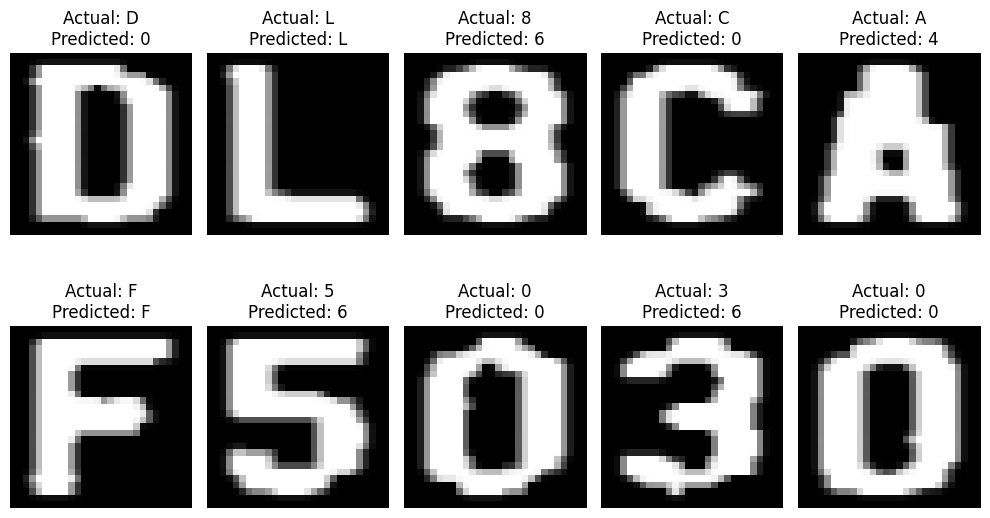

In [27]:
def fix_dimension(img):
    # Ensure the image has 3 channels (RGB)
    if len(img.shape) == 2:  # If grayscale, convert to RGB
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    elif img.shape[2] == 1:  # If single channel, convert to RGB
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    return img

def show_results(model):
    dic = {i: c for i, c in enumerate('0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ')}
    
    output = []
    
    for ch in char_list:
        # Convert to uint8 if necessary
        if ch.dtype != np.uint8:
            ch = ch.astype(np.uint8)

        img_ = cv2.resize(ch, (28, 28))
        img_reshaped = fix_dimension(img_)
        img_reshaped = img_reshaped.reshape(1, 28, 28, 3) 
        
        # Update to use model.predict() instead of predict_classes()
        y_pred_probabilities = model.predict(img_reshaped)
        y_ = np.argmax(y_pred_probabilities)  # Get the index of the highest probability
        
        character = dic[y_]
        output.append(character)
        
    plate_number = ''.join(output)
    
    return plate_number, output  # Return both plate number and predicted characters

# Load image and segment characters
img = cv2.imread('car_plate.png')
char_list = segment_characters(img)

# Display segmented characters
for i in range(len(char_list)):
    plt.subplot(1, len(char_list), i + 1)
    plt.imshow(char_list[i], cmap='gray')
    plt.axis('off')
plt.show()

# Assuming 'model' is already defined and loaded
predicted_plate_number, predicted_characters = show_results(model)
print("Detected Plate Number:", predicted_plate_number)

# Display characters with actual vs predicted
plt.figure(figsize=(10, 6))

# Calculate number of characters
num_chars = len(char_list)

# Determine rows and columns for subplots
cols = 5  # You can adjust this based on your preference
rows = (num_chars + cols - 1) // cols  # Calculate required rows

for i, ch in enumerate(char_list):
    if ch is None or not isinstance(ch, np.ndarray):
        print(f"Skipping invalid image at index {i}.")
        continue
    
    try:
        img_reshaped = cv2.resize(ch.astype(np.uint8), (28, 28))  # Ensure correct type
        
        plt.subplot(rows, cols, i + 1)  # Use calculated rows and cols
        plt.imshow(cv2.cvtColor(img_reshaped, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for display
        plt.axis('off')  # Hide axes for clarity
        
        # Display actual vs predicted in the title
        if i < len(actual_characters):  # Ensure we don't exceed the actual characters list
            plt.title(f'Actual: {actual_characters[i]}\nPredicted: {predicted_characters[i]}')
        else:
            plt.title(f'Predicted: {predicted_characters[i]}')  # In case there's no actual character

    except Exception as e:
        print(f"Error displaying image at index {i}: {e}")
        continue

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()
